In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load
# ----------------------------
prices = pd.read_csv("../../../../data_capsule/ROUND_3/prices_round_3_day_0.csv", sep=";")
trades = pd.read_csv("../../../../data_capsule/ROUND_3/trades_round_3_day_0.csv", sep=";")

PROD = "HYDROGEL_PACK"
p = prices.loc[prices["product"].eq(PROD)].sort_values("timestamp").reset_index(drop=True).copy()
t = trades.loc[trades["symbol"].eq(PROD)].sort_values("timestamp").reset_index(drop=True).copy()

# ----------------------------
# Tunable smoothing knobs
# ----------------------------
ROLL_BOOK = 9      # imbalance smoothing
ROLL_MEAN = 30     # rolling mean for deviation
EWMA_SPAN = 20     # smooth mid
ROLL_TRADE = 7     # trade smoothing
FWD_HORIZON = 5    # future return horizon in book snapshots

# ----------------------------
# Book features
# ----------------------------
# Level 3 is mostly missing here, so use levels 1-2 for cleaner signals.
p["bid_depth"] = p[["bid_volume_1", "bid_volume_2"]].sum(axis=1, min_count=1)
p["ask_depth"] = p[["ask_volume_1", "ask_volume_2"]].sum(axis=1, min_count=1)

den = (p["bid_depth"] + p["ask_depth"]).replace(0, np.nan)
p["imbalance_raw"] = (p["bid_depth"] - p["ask_depth"]) / den
p["imbalance"] = p["imbalance_raw"].rolling(ROLL_BOOK, center=True, min_periods=1).median()

p["mid_smooth"] = p["mid_price"].ewm(span=EWMA_SPAN, adjust=False).mean()
p["rolling_mean_mid"] = p["mid_price"].rolling(ROLL_MEAN, min_periods=5).mean()
p["deviation_mid_mean"] = p["mid_price"] - p["rolling_mean_mid"]
p["deviation_mid_mean_smooth"] = p["deviation_mid_mean"].rolling(11, center=True, min_periods=1).median()

p["fwd_return_5"] = p["mid_price"].shift(-FWD_HORIZON) / p["mid_price"] - 1

# ----------------------------
# Align trades to latest book snapshot
# ----------------------------
book = p[["timestamp", "mid_price", "mid_smooth", "imbalance", "rolling_mean_mid"]].copy()
t = pd.merge_asof(t, book, on="timestamp", direction="backward", tolerance=250)

# Signed volume from trade price vs contemporaneous mid
t["signed_qty"] = np.where(
    t["price"] > t["mid_price"], t["quantity"],
    np.where(t["price"] < t["mid_price"], -t["quantity"], 0)
)
t["notional"] = t["price"] * t["quantity"]

trade_ts = (
    t.groupby("timestamp", as_index=False)
     .agg(
         trade_qty=("quantity", "sum"),
         trade_notional=("notional", "sum"),
         signed_qty=("signed_qty", "sum"),
         mid_price=("mid_price", "last"),
         imbalance=("imbalance", "last"),
     )
)

trade_ts["trade_vwap"] = trade_ts["trade_notional"] / trade_ts["trade_qty"]
trade_ts["trade_minus_mid"] = trade_ts["trade_vwap"] - trade_ts["mid_price"]
trade_ts["trade_qty_smooth"] = trade_ts["trade_qty"].rolling(ROLL_TRADE, min_periods=1).median()
trade_ts["trade_minus_mid_smooth"] = trade_ts["trade_minus_mid"].rolling(ROLL_TRADE, min_periods=1).median()
trade_ts["cum_signed_qty"] = trade_ts["signed_qty"].cumsum()



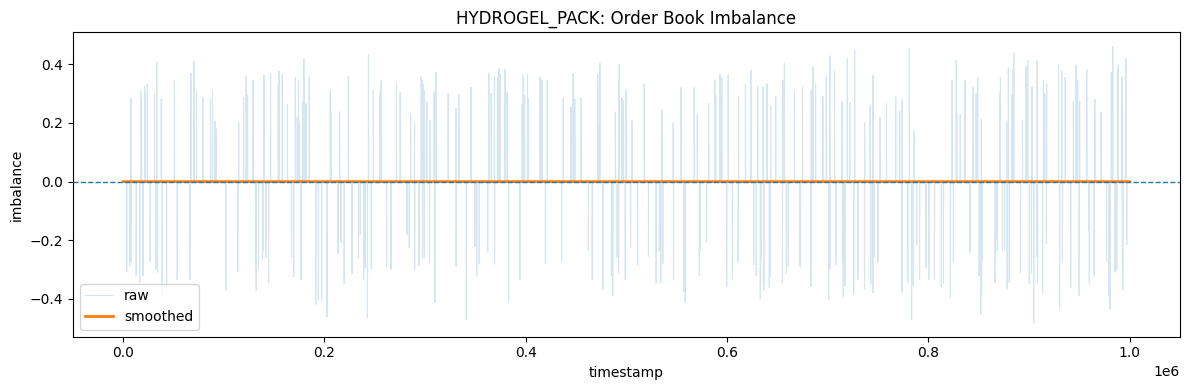

In [8]:
def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / s.std(ddof=0)

# ----------------------------
# 1) Order book imbalance
# ----------------------------
plt.figure(figsize=(12, 4))
plt.plot(p["timestamp"], p["imbalance_raw"], alpha=0.18, linewidth=0.8, label="raw")
plt.plot(p["timestamp"], p["imbalance"], linewidth=2, label="smoothed")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Order Book Imbalance")
plt.xlabel("timestamp")
plt.ylabel("imbalance")
plt.legend()
plt.tight_layout()


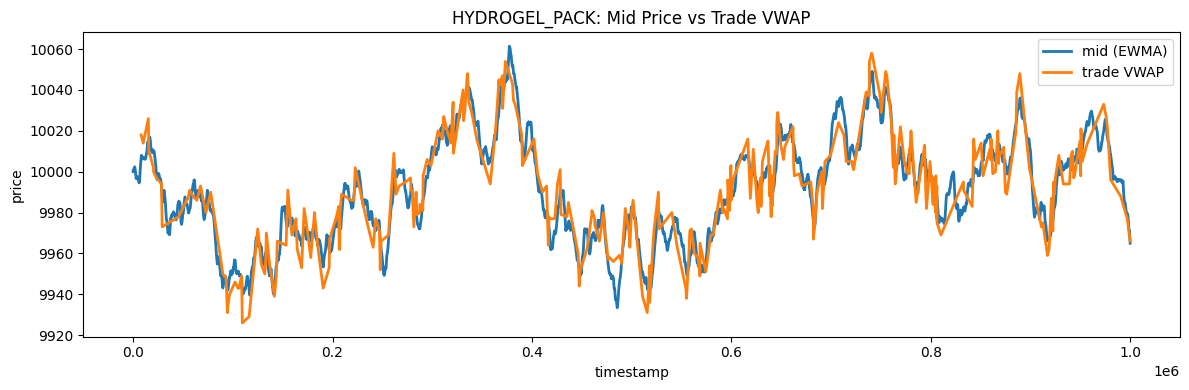

In [9]:

# ----------------------------
# 2) Mid price vs trade VWAP
# ----------------------------
plt.figure(figsize=(12, 4))
plt.plot(p["timestamp"], p["mid_smooth"], linewidth=2, label="mid (EWMA)")
plt.plot(trade_ts["timestamp"], trade_ts["trade_vwap"], linewidth=2, label="trade VWAP")
plt.title("HYDROGEL_PACK: Mid Price vs Trade VWAP")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()


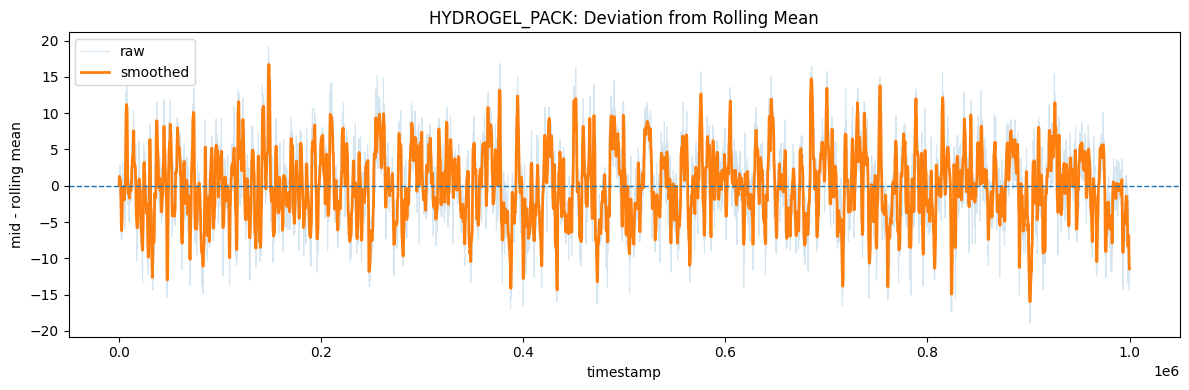

In [10]:

# ----------------------------
# 3) Deviation from rolling mean
# ----------------------------
plt.figure(figsize=(12, 4))
plt.plot(p["timestamp"], p["deviation_mid_mean"], alpha=0.18, linewidth=0.8, label="raw")
plt.plot(p["timestamp"], p["deviation_mid_mean_smooth"], linewidth=2, label="smoothed")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Deviation from Rolling Mean")
plt.xlabel("timestamp")
plt.ylabel("mid - rolling mean")
plt.legend()
plt.tight_layout()


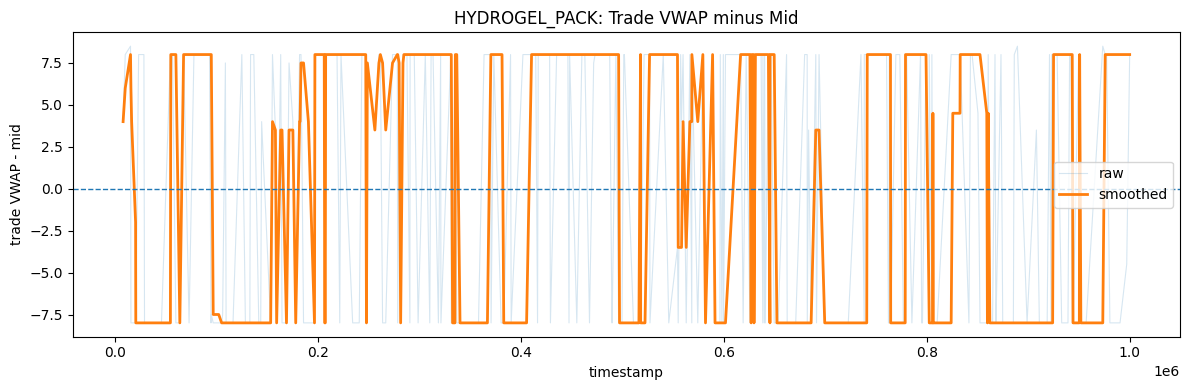

In [11]:

# ----------------------------
# 4) Trade price vs mid
# ----------------------------
plt.figure(figsize=(12, 4))
plt.plot(trade_ts["timestamp"], trade_ts["trade_minus_mid"], alpha=0.18, linewidth=0.8, label="raw")
plt.plot(trade_ts["timestamp"], trade_ts["trade_minus_mid_smooth"], linewidth=2, label="smoothed")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Trade VWAP minus Mid")
plt.xlabel("timestamp")
plt.ylabel("trade VWAP - mid")
plt.legend()
plt.tight_layout()


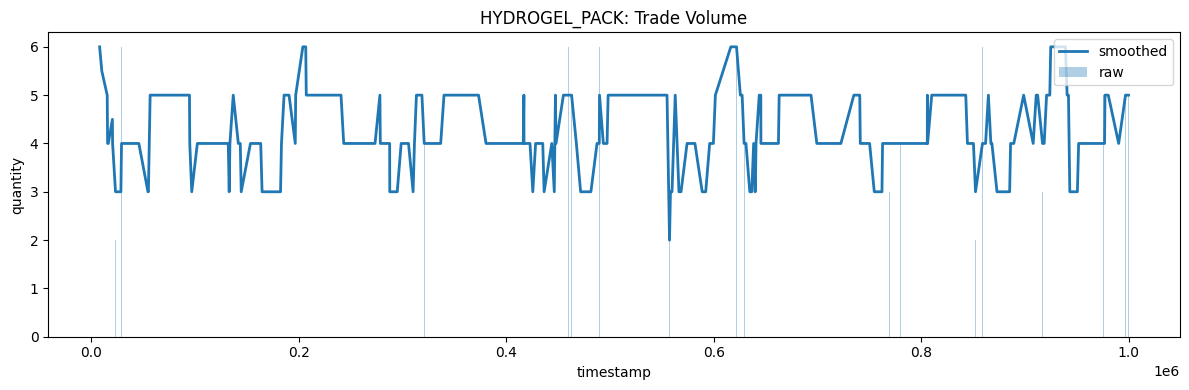

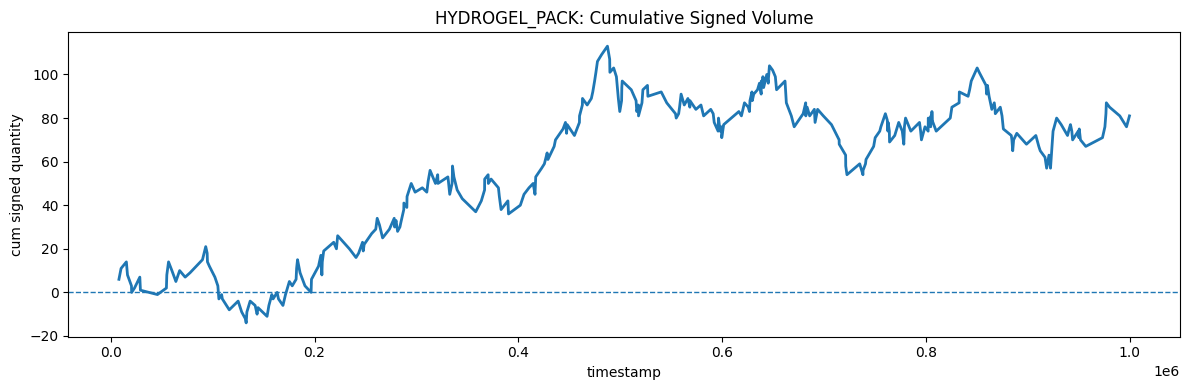

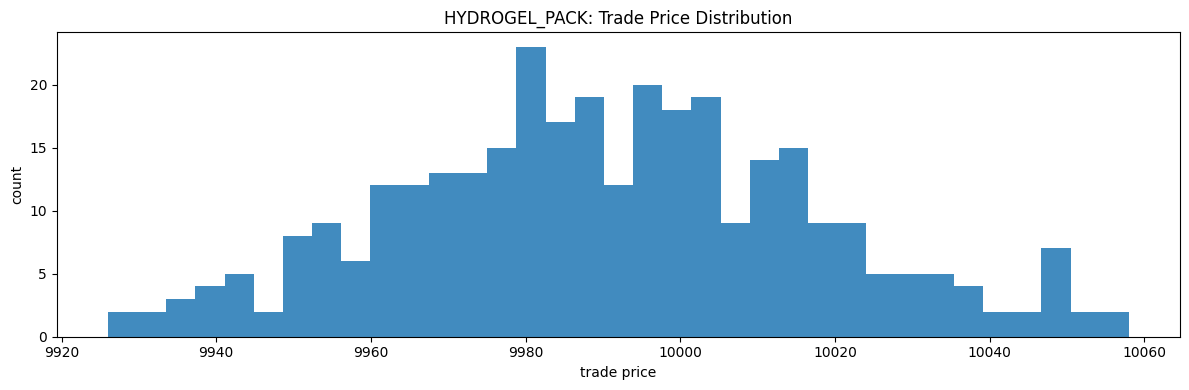

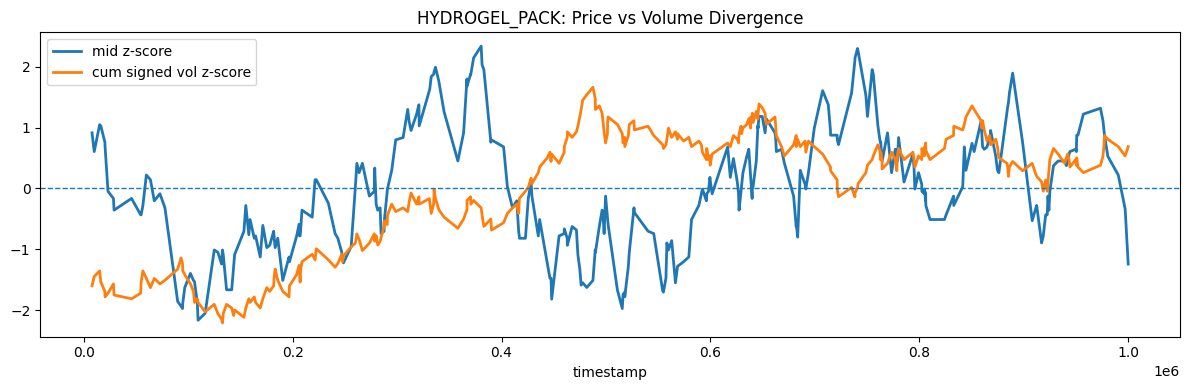

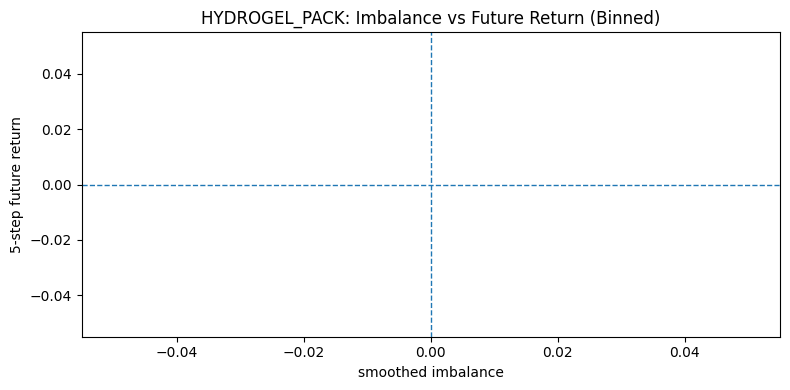

In [12]:

# ----------------------------
# 5) Trade volume spikes
# ----------------------------
plt.figure(figsize=(12, 4))
plt.bar(trade_ts["timestamp"], trade_ts["trade_qty"], width=60, alpha=0.35, label="raw")
plt.plot(trade_ts["timestamp"], trade_ts["trade_qty_smooth"], linewidth=2, label="smoothed")
plt.title("HYDROGEL_PACK: Trade Volume")
plt.xlabel("timestamp")
plt.ylabel("quantity")
plt.legend()
plt.tight_layout()

# ----------------------------
# 6) Signed volume
# ----------------------------
plt.figure(figsize=(12, 4))
plt.plot(trade_ts["timestamp"], trade_ts["cum_signed_qty"], linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Cumulative Signed Volume")
plt.xlabel("timestamp")
plt.ylabel("cum signed quantity")
plt.tight_layout()

# ----------------------------
# 7) Trade price clustering
# ----------------------------
plt.figure(figsize=(12, 4))
plt.hist(t["price"].dropna(), bins=35, alpha=0.85)
plt.title("HYDROGEL_PACK: Trade Price Distribution")
plt.xlabel("trade price")
plt.ylabel("count")
plt.tight_layout()

# ----------------------------
# 8) Price vs volume divergence
# ----------------------------
aligned = trade_ts.dropna(subset=["mid_price"]).copy()
aligned["mid_z"] = zscore(aligned["mid_price"])
aligned["cum_signed_z"] = zscore(aligned["cum_signed_qty"].fillna(0))

plt.figure(figsize=(12, 4))
plt.plot(aligned["timestamp"], aligned["mid_z"], linewidth=2, label="mid z-score")
plt.plot(aligned["timestamp"], aligned["cum_signed_z"], linewidth=2, label="cum signed vol z-score")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Price vs Volume Divergence")
plt.xlabel("timestamp")
plt.legend()
plt.tight_layout()

# ----------------------------
# 9) Imbalance vs future returns
# Use binned means for a much cleaner relationship plot.
# ----------------------------
tmp = p[["imbalance", "fwd_return_5"]].dropna().copy()
tmp["bin"] = pd.qcut(tmp["imbalance"], 20, duplicates="drop")
binned = tmp.groupby("bin", observed=True).agg(
    imbalance=("imbalance", "mean"),
    fwd_return_5=("fwd_return_5", "mean")
).reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(binned["imbalance"], binned["fwd_return_5"], marker="o", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("HYDROGEL_PACK: Imbalance vs Future Return (Binned)")
plt.xlabel("smoothed imbalance")
plt.ylabel(f"{FWD_HORIZON}-step future return")
plt.tight_layout()

plt.show()